In [1]:
%reset -f
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

Week 1 code

In [2]:
power_data_1 = pd.read_csv("Plant_1_Generation_Data.csv")
weather_data_1 = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")
power_data_2 = pd.read_csv("Plant_2_Generation_Data.csv")
weather_data_2 = pd.read_csv("Plant_2_Weather_Sensor_Data.csv")

# Only this file has a different date time format for some reason
power_data_1['DATE_TIME'] = pd.to_datetime(power_data_1['DATE_TIME'], format="%d-%m-%Y %H:%M")
power_data_2['DATE_TIME'] = pd.to_datetime(power_data_2['DATE_TIME'], format="%Y-%m-%d %H:%M:%S")

weather_data_1['DATE_TIME'] = pd.to_datetime(weather_data_1['DATE_TIME'], format="%Y-%m-%d %H:%M:%S")
weather_data_2['DATE_TIME']= pd.to_datetime(weather_data_2['DATE_TIME'], format="%Y-%m-%d %H:%M:%S")

# Merge power and weather data simply via concatenation
power_data = pd.concat([power_data_1, power_data_2])
weather_data = pd.concat([weather_data_1, weather_data_2])

display(power_data, weather_data)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0
...,...,...,...,...,...,...,...
67693,2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.0,520758.0
67694,2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.0,121131356.0
67695,2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.0,2427691.0
67696,2020-06-17 23:45:00,4136001,xMbIugepa2P7lBB,0.0,0.0,4218.0,106896394.0


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0
...,...,...,...,...,...,...
3254,2020-06-17 22:45:00,4136001,iq8k7ZNt4Mwm3w0,23.511703,22.856201,0.0
3255,2020-06-17 23:00:00,4136001,iq8k7ZNt4Mwm3w0,23.482282,22.744190,0.0
3256,2020-06-17 23:15:00,4136001,iq8k7ZNt4Mwm3w0,23.354743,22.492245,0.0
3257,2020-06-17 23:30:00,4136001,iq8k7ZNt4Mwm3w0,23.291048,22.373909,0.0


In [3]:

# Filter for specific columns because of duplicates and unneeded columns
power_data_1 = power_data_1[['DATE_TIME', 'DC_POWER', 'SOURCE_KEY', 'PLANT_ID']]
weather_data_1 = weather_data_1[['DATE_TIME', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]

power_data_2 = power_data_2[['DATE_TIME', 'DC_POWER', 'SOURCE_KEY', 'PLANT_ID']]
weather_data_2 = weather_data_2[['DATE_TIME', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]

# Merge the power and weather data based on the date and time
merged_data_1 = pd.merge(power_data_1, weather_data_1, on='DATE_TIME', how='inner')
merged_data_2 = pd.merge(power_data_2, weather_data_2, on='DATE_TIME', how='inner')

merged_data = pd.concat([merged_data_1, merged_data_2])

display(merged_data)

,DATE_TIME,DC_POWER,SOURCE_KEY,PLANT_ID,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
0,2020-05-15 00:00:00,0.0,1BY6WEcLGh8j5v7,4135001,0.0,25.184316,22.857507
1,2020-05-15 00:00:00,0.0,1IF53ai7Xc0U56Y,4135001,0.0,25.184316,22.857507
2,2020-05-15 00:00:00,0.0,3PZuoBAID5Wc2HD,4135001,0.0,25.184316,22.857507
3,2020-05-15 00:00:00,0.0,7JYdWkrLSPkdwr4,4135001,0.0,25.184316,22.857507
4,2020-05-15 00:00:00,0.0,McdE0feGgRqW7Ca,4135001,0.0,25.184316,22.857507
...,...,...,...,...,...,...,...
67693,2020-06-17 23:45:00,0.0,q49J1IKaHRwDQnt,4136001,0.0,23.202871,22.535908
67694,2020-06-17 23:45:00,0.0,rrq4fwE8jgrTyWY,4136001,0.0,23.202871,22.535908
67695,2020-06-17 23:45:00,0.0,vOuJvMaM2sgwLmb,4136001,0.0,23.202871,22.535908
67696,2020-06-17 23:45:00,0.0,xMbIugepa2P7lBB,4136001,0.0,23.202871,22.535908


Final merged dataframe is contained in the merged_data variable

Week 2 code

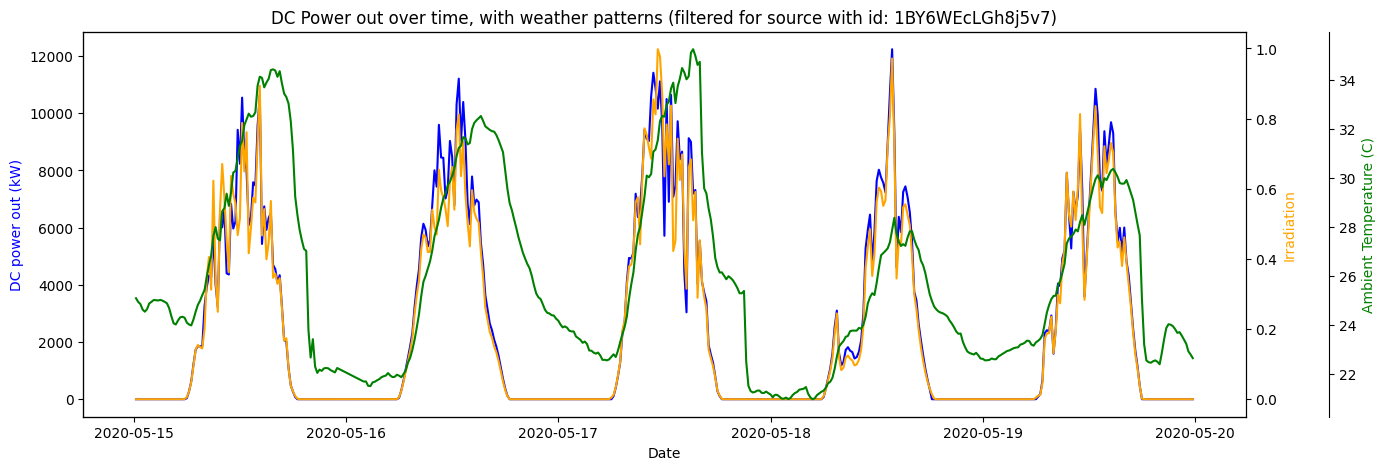

In [22]:
# Pick a date range, I just did the first 5 days
START_DATE = pd.to_datetime("2020-05-15 00:00:00")
END_DATE = pd.to_datetime("2020-05-20 00:00:00")

# Pick an inverter, I just did the first one
INVERTER_ID = "1BY6WEcLGh8j5v7"

# Filter for the specific conditions above
one_inverter_5_day = merged_data[
    (merged_data['SOURCE_KEY'] == INVERTER_ID) &
    (merged_data['DATE_TIME'] > START_DATE) &
    (merged_data['DATE_TIME'] < END_DATE)
]

fig, ax = plt.subplots(figsize = (15, 5))
ax.set_title(f'DC Power out over time, with weather patterns (filtered for source with id: {INVERTER_ID})')

# DC Power out as main variable
color = 'blue'
ax.plot(one_inverter_5_day.DATE_TIME, one_inverter_5_day.DC_POWER, color = color)
ax.set_xlabel('Date')
ax.set_ylabel('DC power out (kW)', color = color)

# Irradiation as second
color = 'orange'
ax2 = ax.twinx()
ax2.plot(one_inverter_5_day.DATE_TIME, one_inverter_5_day.IRRADIATION, color = color)
ax2.set_ylabel('Irradiation', color = color)

# Ambient temperature as third variable
color = 'green'
ax3 = ax.twinx()
ax3.plot(one_inverter_5_day.DATE_TIME, one_inverter_5_day.AMBIENT_TEMPERATURE, color = color)
ax3.set_ylabel('Ambient Temperature (C)', color = color)
ax3.spines['right'].set_position(('outward', 60))

plt.show()

Week 3 code

Graphed seperately because of differing scales

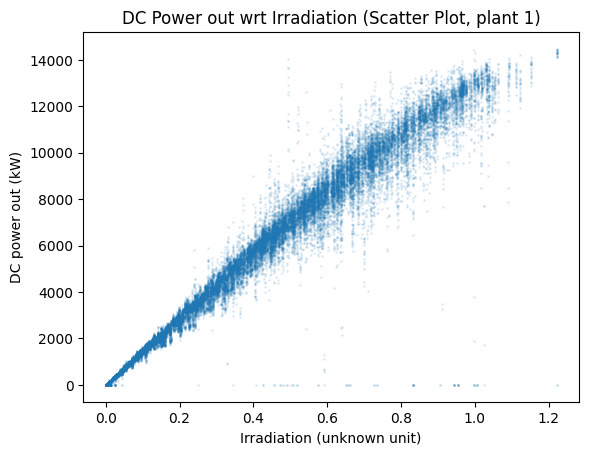

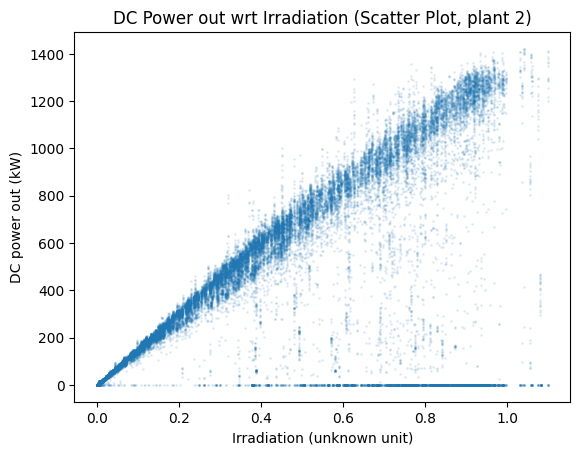

In [5]:
# Simple scatter plots, small points and low alpha because of the sheer amount of data
fig_1, axes_1 = plt.subplots()
axes_1.scatter(merged_data_1.IRRADIATION, merged_data_1.DC_POWER, alpha=0.1, s=1)
axes_1.set_title("DC Power out wrt Irradiation (Scatter Plot, plant 1)")
axes_1.set_xlabel("Irradiation (unknown unit)")
axes_1.set_ylabel("DC power out (kW)")

fig_2, axes_2 = plt.subplots()
axes_2.scatter(merged_data_2.IRRADIATION, merged_data_2.DC_POWER, alpha=0.1, s=1)
axes_2.set_title("DC Power out wrt Irradiation (Scatter Plot, plant 2)")
axes_2.set_xlabel("Irradiation (unknown unit)")
axes_2.set_ylabel("DC power out (kW)")

plt.show()

In [6]:
# Filter for when there is no power but irradiation is significant (likely equipment failure)
filtered_for_error = merged_data[(merged_data['DC_POWER'] == 0.0) & (merged_data['IRRADIATION'] > 0.5)]

# Get a list of all the timestamps
timestamps = filtered_for_error[['DATE_TIME']]

# Convenient textual form is a list of times and how many inverters were failed at that time
ts_count = timestamps.groupby(timestamps.columns.tolist(), as_index=False).size()
display(ts_count)

,DATE_TIME,size
0,2020-05-15 09:45:00,4
1,2020-05-15 10:00:00,4
2,2020-05-15 10:15:00,7
3,2020-05-15 10:30:00,7
4,2020-05-15 10:45:00,7
...,...,...
531,2020-06-15 14:00:00,2
532,2020-06-16 11:45:00,4
533,2020-06-16 12:00:00,3
534,2020-06-16 12:45:00,1


Week 4 code: Exploratory Data Analysis

In [7]:
print("Data types: ")
print(merged_data.info()) # look at data types
print()
print("Null value counts: ")
print(merged_data.isnull().sum()) # check for null values
print()
print("Duplicate value count: ")
print(merged_data.duplicated().sum()) # check for duplicates
# Data is clean so move on to analysis

Data types: 
<class 'pandas.core.frame.DataFrame'>
Index: 136472 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   DATE_TIME            136472 non-null  datetime64[ns]
 1   DC_POWER             136472 non-null  float64       
 2   SOURCE_KEY           136472 non-null  object        
 3   PLANT_ID             136472 non-null  int64         
 4   IRRADIATION          136472 non-null  float64       
 5   AMBIENT_TEMPERATURE  136472 non-null  float64       
 6   MODULE_TEMPERATURE   136472 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 8.3+ MB
None

Null value counts: 
DATE_TIME              0
DC_POWER               0
SOURCE_KEY             0
PLANT_ID               0
IRRADIATION            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
dtype: int64

Duplicate value count: 
0


In [8]:
merged_data.describe() # show basic statistics

,DATE_TIME,DC_POWER,PLANT_ID,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
count,136472,136472.000000,1.364720e+05,136472.000000,136472.000000,136472.000000
mean,2020-06-01 09:22:57.605662464,1708.373962,4.135497e+06,0.230767,26.763066,31.920744
min,2020-05-15 00:00:00,0.000000,4.135001e+06,0.000000,20.398505,18.140415
25%,2020-05-23 23:00:00,0.000000,4.135001e+06,0.000000,23.637604,22.411698
50%,2020-06-01 18:45:00,5.993333,4.135001e+06,0.026213,25.908122,26.413755
75%,2020-06-09 21:45:00,1155.595000,4.136001e+06,0.442961,29.266583,40.778583
max,2020-06-17 23:45:00,14471.125000,4.136001e+06,1.221652,39.181638,66.635953
std,NaN,3222.079306,4.999863e+02,0.305652,3.897340,11.803674


In [9]:
def show_distributions(df: pd.DataFrame, idx: str):
  # Plot distribution of a specific column
  sns.histplot(df[idx], kde=True)
  plt.title(idx + ' Distribution')
  plt.show()

  # Box plot to detect outliers
  sns.boxplot(x=df[idx])
  plt.title(idx + ' Box Plot')
  plt.show()

In [10]:
def show_relationship(df: pd.DataFrame, x: str, y: str):
  sns.scatterplot(data=df, x=x, y=y)
  plt.title(x + ' VS ' + y)
  plt.show()
  print('Correlation ' + df[x].corr(df[y]))

In [11]:
merged_data['DC_POWER_NORM'] = merged_data.groupby('SOURCE_KEY')['DC_POWER'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0
)

merged_data['HOUR_OF_DAY'] = merged_data['DATE_TIME'].dt.hour
merged_data['TEMP_DIFF'] = merged_data['MODULE_TEMPERATURE'] - merged_data['AMBIENT_TEMPERATURE']

merged_data_nonzero_power = merged_data[merged_data['DC_POWER'] > 0]

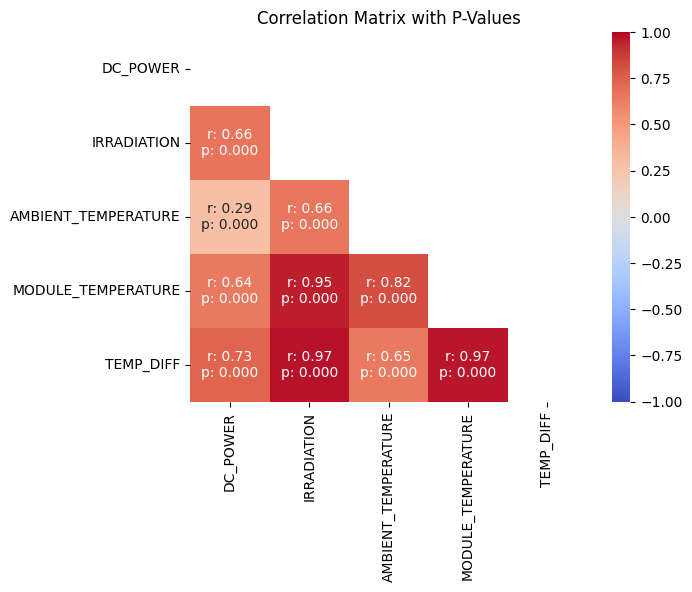

In [12]:
merged_data_numerical = merged_data.select_dtypes(include=[np.number])[['DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'TEMP_DIFF']] # cant correlate non numerical fields
p_matrix = merged_data_numerical.corr(method=lambda x, y: pearsonr(x, y)[1]) # get p-value matrix
r_matrix = merged_data_numerical.corr() # get r value matrix

mask = np.triu(np.ones_like(r_matrix, dtype=bool))

labels = np.asarray(
    [
        f"r: {r:.2f}\np: {p:.3f}" for r, p in
        zip(r_matrix.values.flatten(), p_matrix.values.flatten())
    ]
  ).reshape(r_matrix.shape)
sns.heatmap(r_matrix, annot=labels, fmt="", cmap="coolwarm", vmin=-1, vmax=1, cbar=True, mask=mask)
plt.title("Correlation Matrix with P-Values")
plt.show()

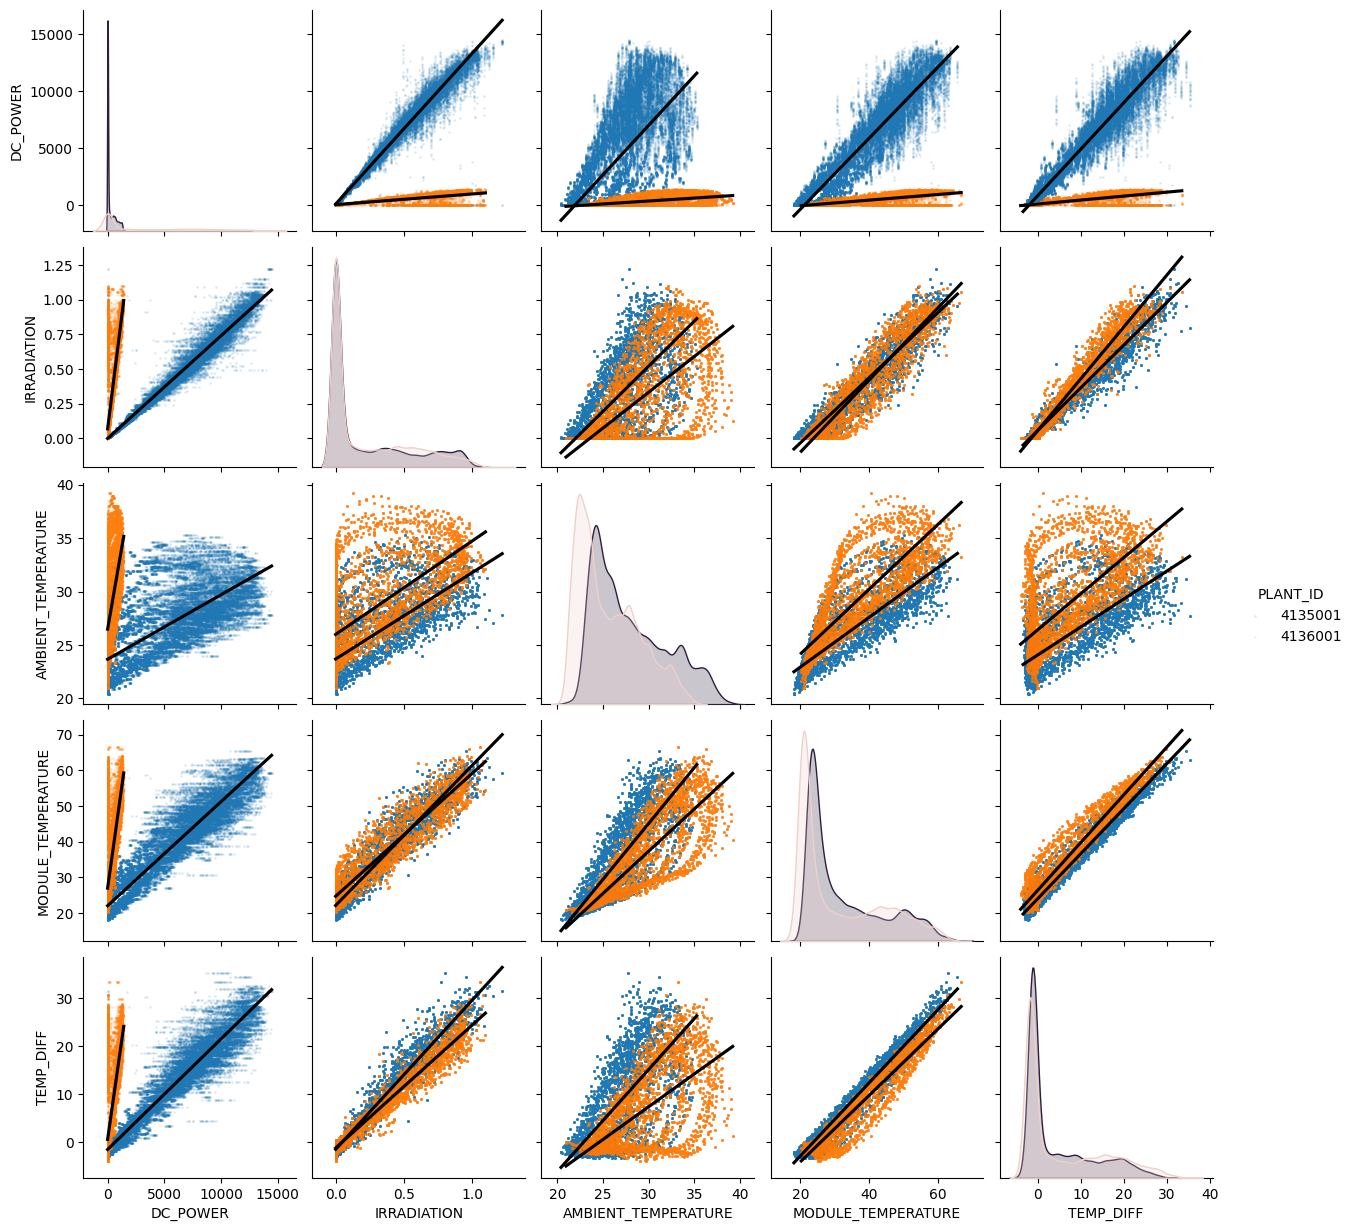

In [13]:
features = ['DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'TEMP_DIFF', 'PLANT_ID']
sns.pairplot(merged_data[features], diag_kind='kde', kind='reg', hue='PLANT_ID', plot_kws={
                 'line_kws': {'color': 'black'},
                 'scatter_kws': {'s': 1, 'alpha': 0.1}
             })
plt.show()

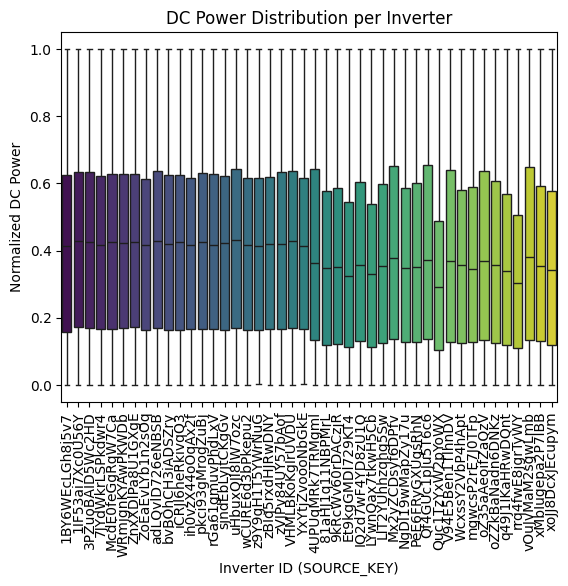

In [14]:
sns.boxplot(data=merged_data_nonzero_power, x='SOURCE_KEY', y='DC_POWER_NORM', palette='viridis', hue='SOURCE_KEY', legend=False)

plt.title('DC Power Distribution per Inverter')
plt.xticks(rotation=90) # Rotates the inverter names so they don't overlap
plt.ylabel('Normalized DC Power')
plt.xlabel('Inverter ID (SOURCE_KEY)')
plt.show()

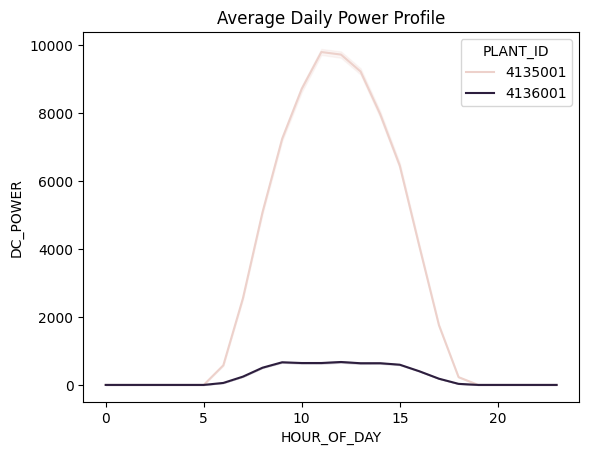

In [15]:


# Plot daily average production profiles
sns.lineplot(data=merged_data, x='HOUR_OF_DAY', y='DC_POWER', hue='PLANT_ID')
plt.title("Average Daily Power Profile")
plt.show()

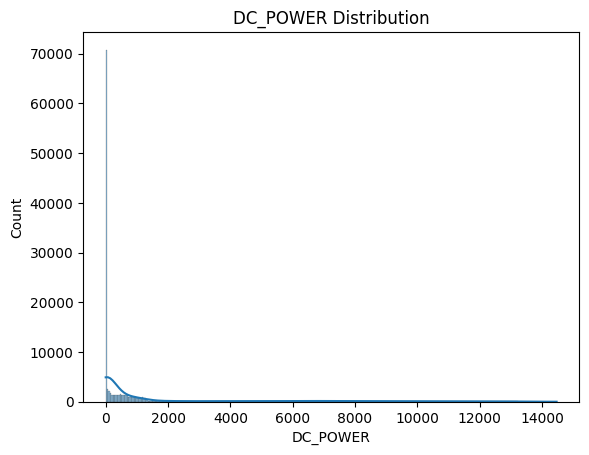

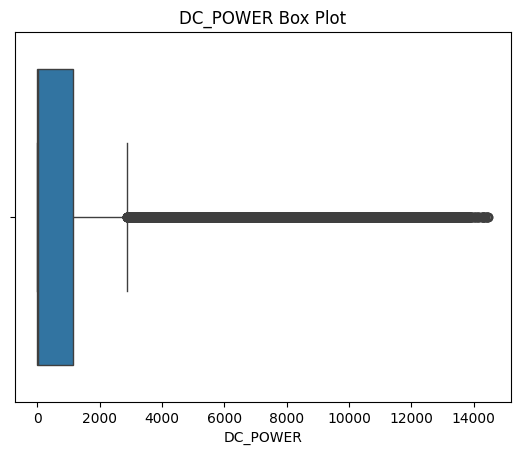

In [16]:
show_distributions(merged_data, 'DC_POWER')

High number of zeroes, due to night time, what if we filter those out?

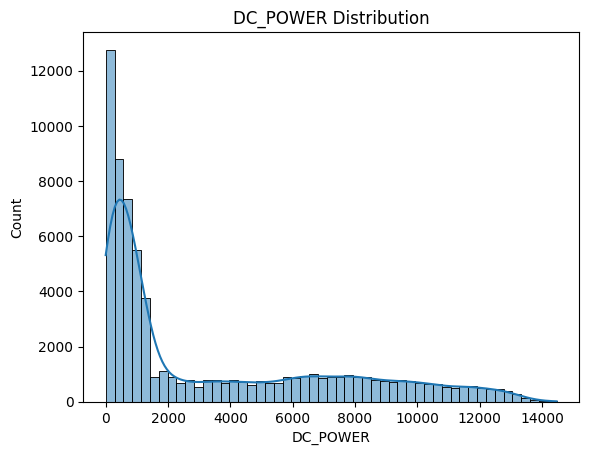

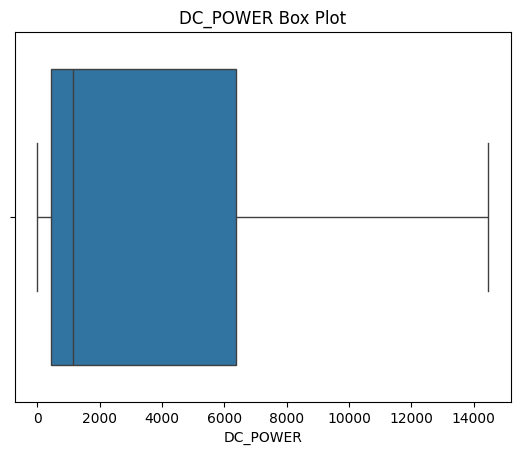

In [17]:
show_distributions(merged_data_nonzero_power, 'DC_POWER')

Might be a log distribution, try plotting ln('DC_POWER')

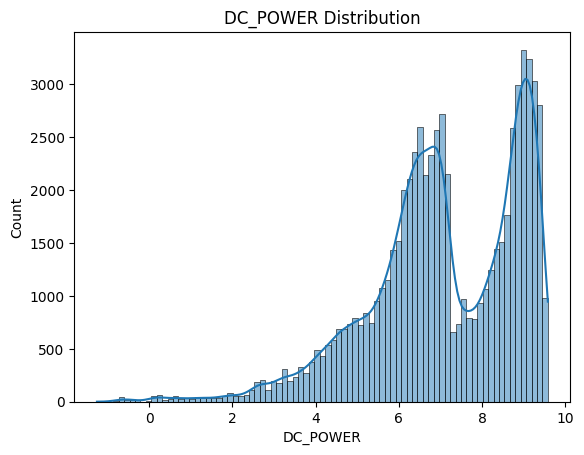

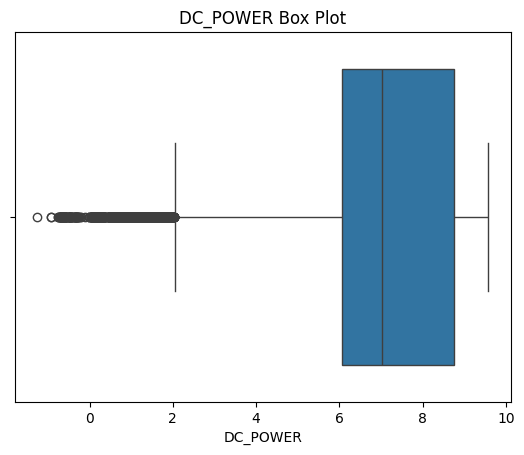

In [18]:
merged_data_filtered_with_power_log = merged_data_nonzero_power.copy()
merged_data_filtered_with_power_log['DC_POWER'] = np.log(merged_data_filtered_with_power_log['DC_POWER'])
show_distributions(merged_data_filtered_with_power_log, 'DC_POWER')

Looks like two peak distribution, so there are likely two states the panels like to hover around (cloudy vs sunny days?), excluding night time